# Medical Appointment No Show Analysis
### A data analysis project investigating patterns behind missed medical appointments

Author: Odoh Ekenedirichukwu Johnpaul
Tools: Python, SQL, Power BI

## 1. Import Libraries and Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print(os.getcwd())
df = pd.read_excel("data/raw/Medical-no-show.xlsx")
df.head()

C:\Users\USER\Medical-Noshow-Portfolio


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
df.tail()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
110522,2.572134e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,3.596266e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,1.557663e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,9.213493e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,0,0,0,0,0,1,No
110526,3.775115e+14,5629448,F,2016-04-27T13:30:56Z,2016-06-07T00:00:00Z,54,MARIA ORTIZ,0,0,0,0,0,1,No


# 2. Intial Data Inspection

In [4]:
print(df.shape)
df.info()

(110527, 14)
<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 17.7 MB


In [5]:
df.isna().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

# 3. Data Cleaning

In [7]:
# Rename columns with typos or inconsistent naming for easier reference

df = df.rename(columns={"Hipertension": "Hypertension", "No-show": "No_show"})
df.columns.tolist()

['PatientId',
 'AppointmentID',
 'Gender',
 'ScheduledDay',
 'AppointmentDay',
 'Age',
 'Neighbourhood',
 'Scholarship',
 'Hypertension',
 'Diabetes',
 'Alcoholism',
 'Handcap',
 'SMS_received',
 'No_show']

In [8]:
# Convert ScheduledDay and AppointmentDay to proper datetime

df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
df[['ScheduledDay', 'AppointmentDay']].dtypes

ScheduledDay      datetime64[us, UTC]
AppointmentDay    datetime64[us, UTC]
dtype: object

In [9]:
# Check the negative age issue

df[df['Age'] < 0]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handcap,SMS_received,No_show
99832,4.659432e+14,5775010,F,2016-06-06 08:58:13+00:00,2016-06-06 00:00:00+00:00,-1,ROMÃƒO,0,0,0,0,0,0,No


In [10]:
# Drop the row with an invalid negative age

df = df[df['Age'] >= 0]
print(df.shape)

(110526, 14)


In [11]:
df['Neighbourhood'].unique()

<ArrowStringArray>
[             'JARDIM DA PENHA',                'MATA DA PRAIA',
            'PONTAL DE CAMBURI',                   'REPÃšBLICA',
                   'GOIABEIRAS',                   'ANDORINHAS',
                    'CONQUISTA',               'NOVA PALESTINA',
                     'DA PENHA',                   'TABUAZEIRO',
               'BENTO FERREIRA',                   'SÃƒO PEDRO',
                 'SANTA MARTHA',             'SÃƒO CRISTÃ“VÃƒO',
                     'MARUÃPE',              'GRANDE VITÃ“RIA',
                'SÃƒO BENEDITO',            'ILHA DAS CAIEIRAS',
                 'SANTO ANDRÃ‰',                 'SOLON BORGES',
                       'BONFIM',               'JARDIM CAMBURI',
                  'MARIA ORTIZ',                       'JABOUR',
            'ANTÃ”NIO HONÃ“RIO',                 'RESISTÃŠNCIA',
          'ILHA DE SANTA MARIA',                  'JUCUTUQUARA',
                   'MONTE BELO',              'MÃRIO CYPRESTE',
      

## 3b. Fixing Encoding Issues in Neighbourhood Names

In [12]:
df['Neighbourhood'] = df['Neighbourhood'].str.encode('cp1252', errors='ignore').str.decode('utf-8', errors='ignore')
df['Neighbourhood'].unique()

<ArrowStringArray>
[            'JARDIM DA PENHA',               'MATA DA PRAIA',
           'PONTAL DE CAMBURI',                   'REPÚBLICA',
                  'GOIABEIRAS',                  'ANDORINHAS',
                   'CONQUISTA',              'NOVA PALESTINA',
                    'DA PENHA',                  'TABUAZEIRO',
              'BENTO FERREIRA',                   'SÃO PEDRO',
                'SANTA MARTHA',               'SÃO CRISTÓVÃO',
                      'MARUPE',              'GRANDE VITÓRIA',
                'SÃO BENEDITO',           'ILHA DAS CAIEIRAS',
                 'SANTO ANDRÉ',                'SOLON BORGES',
                      'BONFIM',              'JARDIM CAMBURI',
                 'MARIA ORTIZ',                      'JABOUR',
             'ANTÔNIO HONÓRIO',                 'RESISTÊNCIA',
         'ILHA DE SANTA MARIA',                 'JUCUTUQUARA',
                  'MONTE BELO',               'MRIO CYPRESTE',
               'SANTO ANTÔNIO',     

In [13]:
print("Neighbourhood encoding fixed where possible, 9 of 81 names retain minor unrecoverable character loss")

Neighbourhood encoding fixed where possible, 9 of 81 names retain minor unrecoverable character loss


## 3c. Checking the Handcap Column

In [14]:
df['Handcap'].value_counts()

Handcap
0    108285
1      2042
2       183
3        13
4         3
Name: count, dtype: int64

## 3d. Creating a Simplified Handicap Flag
The original Handcap column ranges from 0 to 4, but values above 1 are extremely rare, so a binary flag is added for easier comparison.

In [15]:
df['Has_Handicap'] = df['Handcap'].apply(lambda x: 1 if x > 0 else 0)
df['Has_Handicap'].value_counts()

Has_Handicap
0    108285
1      2241
Name: count, dtype: int64

## 3e. Checking Value Ranges Across All Categorical Columns

In [16]:
for col in ['Gender', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No_show']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- Gender ---
Gender
F    71839
M    38687
Name: count, dtype: int64

--- Scholarship ---
Scholarship
0    99665
1    10861
Name: count, dtype: int64

--- Hypertension ---
Hypertension
0    88725
1    21801
Name: count, dtype: int64

--- Diabetes ---
Diabetes
0    102583
1      7943
Name: count, dtype: int64

--- Alcoholism ---
Alcoholism
0    107166
1      3360
Name: count, dtype: int64

--- Handcap ---
Handcap
0    108285
1      2042
2       183
3        13
4         3
Name: count, dtype: int64

--- SMS_received ---
SMS_received
0    75044
1    35482
Name: count, dtype: int64

--- No_show ---
No_show
No     88207
Yes    22319
Name: count, dtype: int64



## 4. Descriptive Statistics

In [17]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hypertension,Diabetes,Alcoholism,Handcap,SMS_received,Has_Handicap
count,1.105260e+05,1.105260e+05,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000,110526.000000
mean,1.474934e+14,5.675304e+06,37.089219,0.098266,0.197248,0.071865,0.030400,0.022248,0.321029,0.020276
std,2.560943e+14,7.129544e+04,23.110026,0.297676,0.397923,0.258266,0.171686,0.161543,0.466874,0.140943
min,3.921784e+04,5.030230e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172536e+12,5.640285e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680572e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.438963e+13,5.725523e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000


## 4b. Checking for Outliers in Age

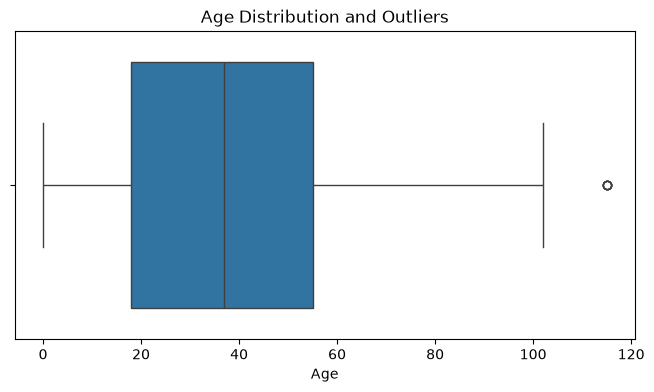

In [18]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Age'])
plt.title('Age Distribution and Outliers')
plt.savefig('visuals/age_outliers.png')
plt.show()

In [19]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
print(f"Number of outliers: {outliers.shape[0]}")

Lower bound: -37.5, Upper bound: 110.5
Number of outliers: 5


## 4c. Checking for Rare Categories in Binary and Categorical Columns
Outlier detection (IQR) applies to continuous numeric data like Age. For binary and categorical columns, the equivalent check is looking at how rare each category is, since a small minority class is not an error, but worth knowing about before analysis.

In [20]:
categorical_cols = ['Gender', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No_show']

for col in categorical_cols:
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100
    print(f"--- {col} ---")
    for value in counts.index:
        print(f"{value}: {counts[value]} rows ({percentages[value]:.2f}%)")
    print()

--- Gender ---
F: 71839 rows (65.00%)
M: 38687 rows (35.00%)

--- Scholarship ---
0: 99665 rows (90.17%)
1: 10861 rows (9.83%)

--- Hypertension ---
0: 88725 rows (80.28%)
1: 21801 rows (19.72%)

--- Diabetes ---
0: 102583 rows (92.81%)
1: 7943 rows (7.19%)

--- Alcoholism ---
0: 107166 rows (96.96%)
1: 3360 rows (3.04%)

--- Handcap ---
0: 108285 rows (97.97%)
1: 2042 rows (1.85%)
2: 183 rows (0.17%)
3: 13 rows (0.01%)
4: 3 rows (0.00%)

--- SMS_received ---
0: 75044 rows (67.90%)
1: 35482 rows (32.10%)

--- No_show ---
No: 88207 rows (79.81%)
Yes: 22319 rows (20.19%)



## 5. Univariate Analysis
Distribution of Age, and the proportions of key categorical variables

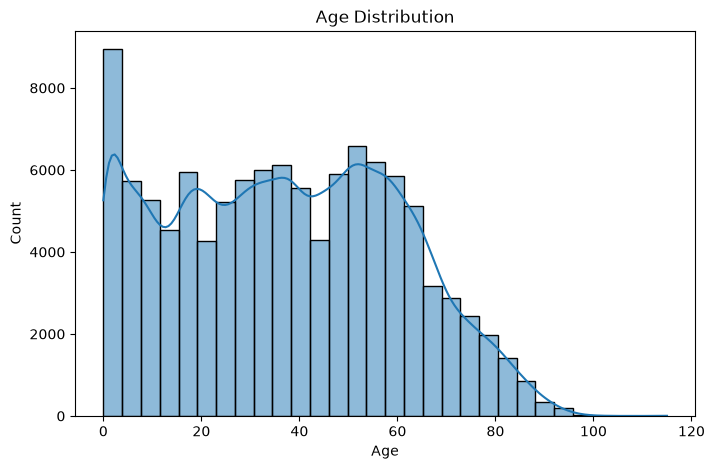

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], kde=True, bins=30)
plt.title('Age Distribution')
plt.savefig('visuals/age_distribution.png')
plt.show()

## 5b. Categorical Breakdown
Proportions of Gender, No_show, SMS_received, and the health condition flags

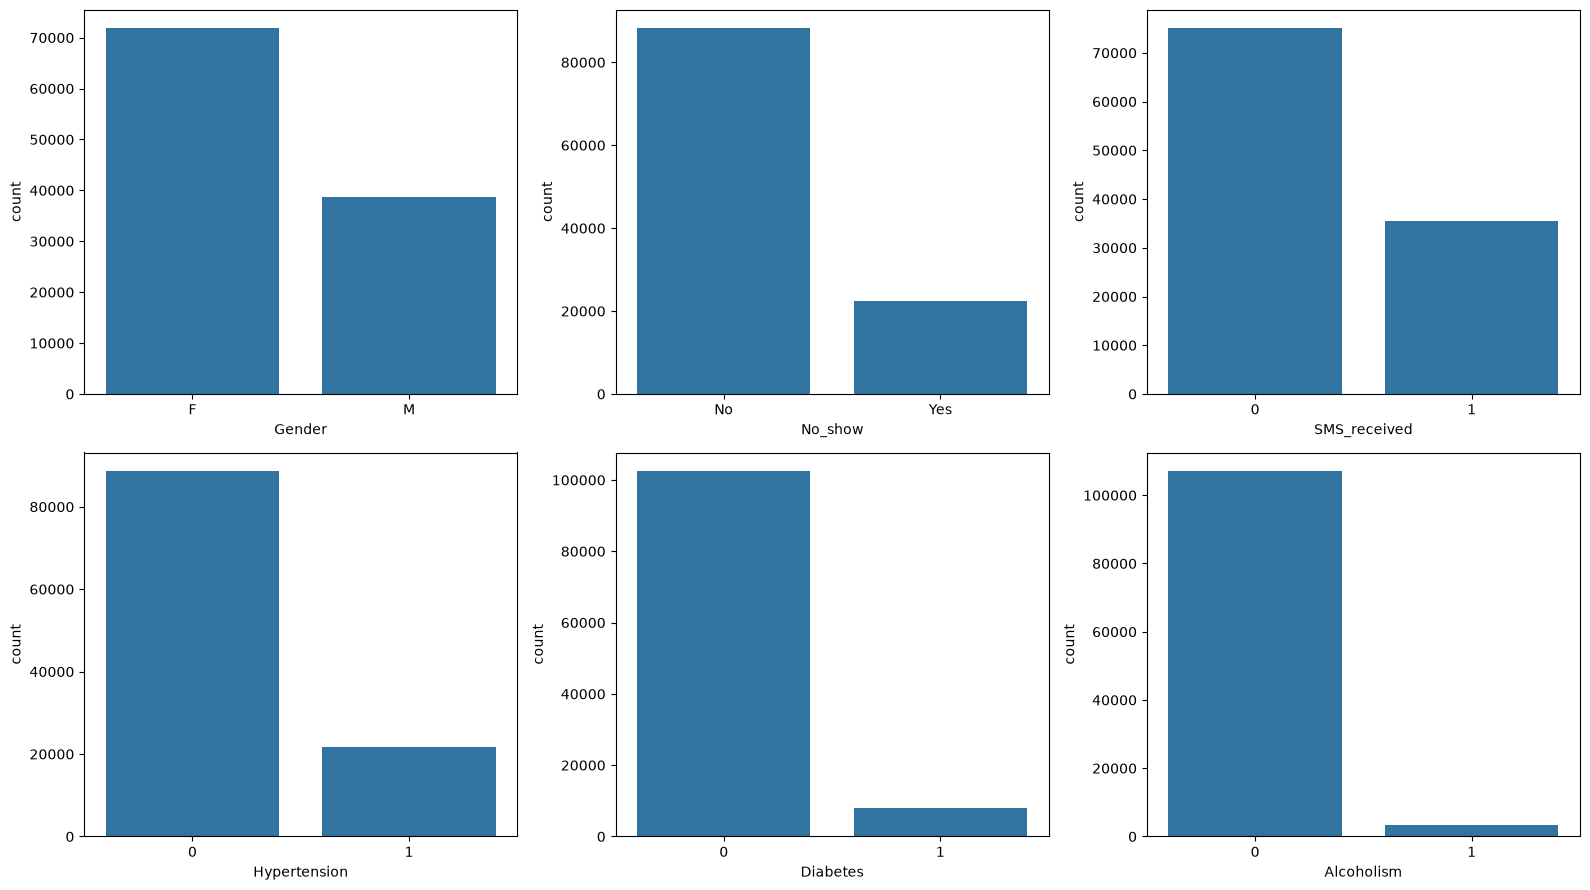

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
sns.countplot(x='Gender', data=df, ax=axes[0,0])
sns.countplot(x='No_show', data=df, ax=axes[0,1])
sns.countplot(x='SMS_received', data=df, ax=axes[0,2])
sns.countplot(x='Hypertension', data=df, ax=axes[1,0])
sns.countplot(x='Diabetes', data=df, ax=axes[1,1])
sns.countplot(x='Alcoholism', data=df, ax=axes[1,2])
plt.tight_layout()
plt.savefig('visuals/categorical_breakdown.png')
plt.show()

## 5c. Interpretation of Categorical Breakdown

- Gender: significantly more female patients than male in this dataset (about 65% vs 35%)
- No_show: roughly 4 out of 5 appointments were kept, about 20% were missed
- SMS_received: about 1 in 3 patients received a reminder text before their appointment
- Hypertension: about 1 in 5 patients have a hypertension diagnosis
- Diabetes: a smaller share, about 7%, have diabetes
- Alcoholism: the smallest group here, about 3%, flagged for alcoholism

## 6. Bivariate Analysis
Checking whether Age, Gender, SMS_received, and health conditions relate to No_show

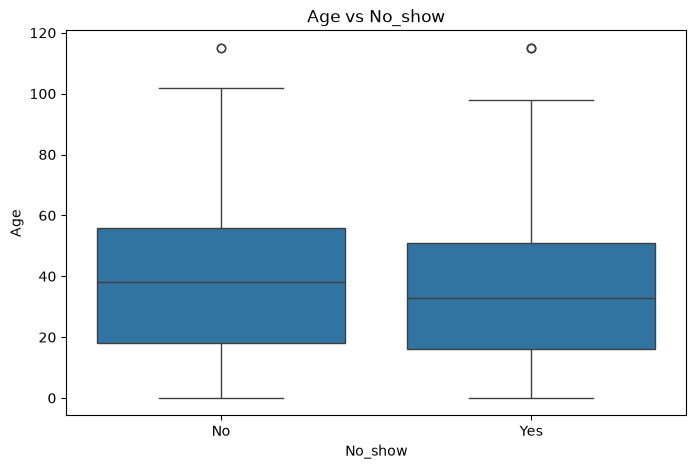

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='No_show', y='Age', data=df)
plt.title('Age vs No_show')
plt.savefig('visuals/age_vs_noshow.png')
plt.show()

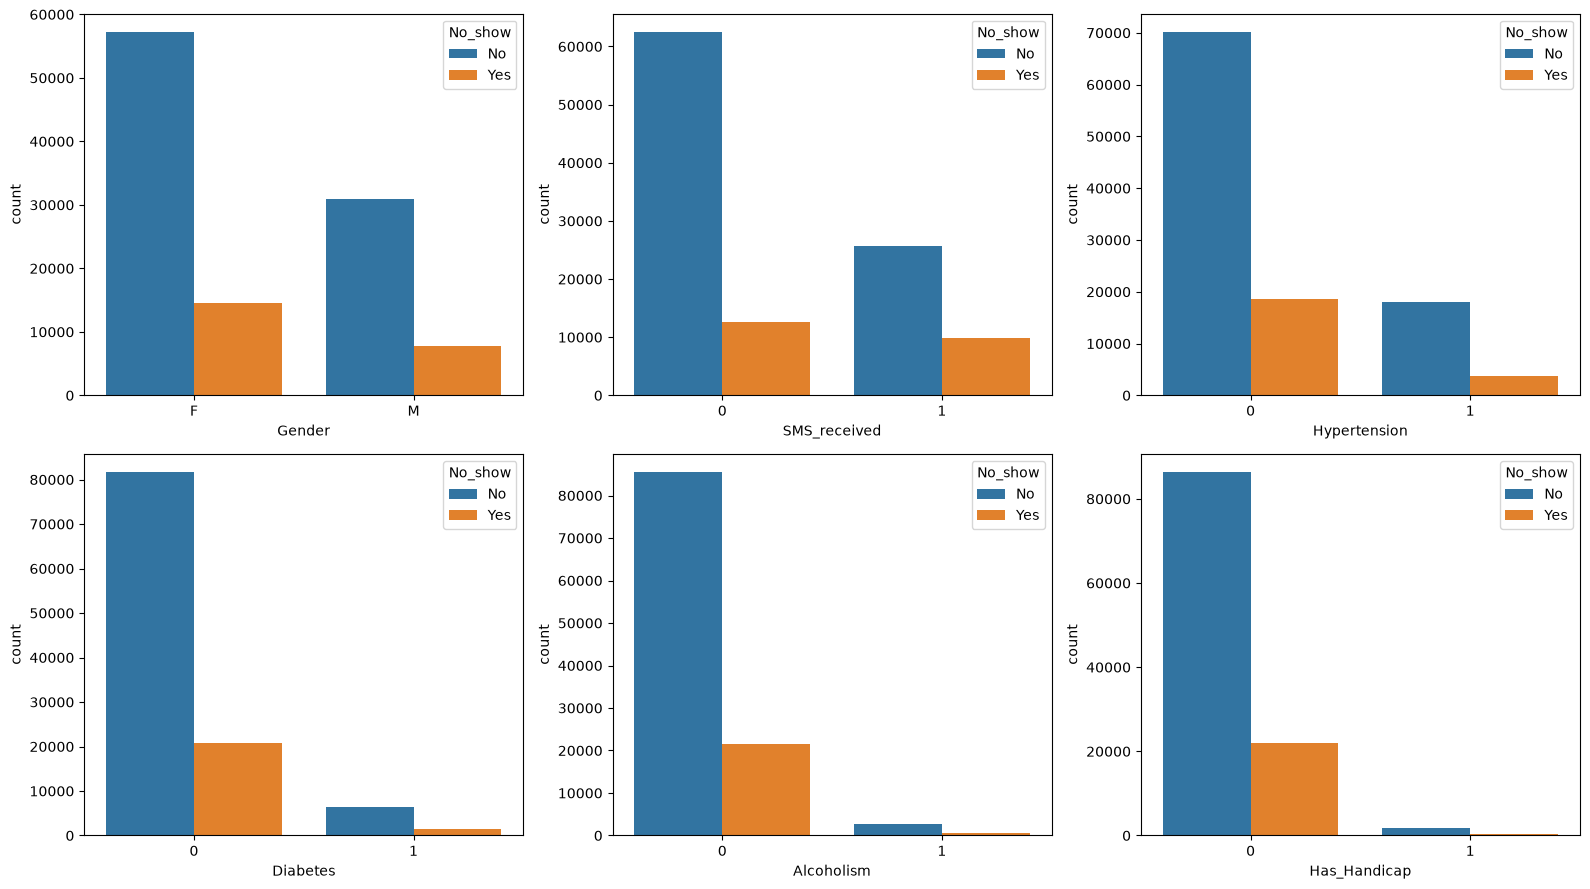

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
sns.countplot(x='Gender', hue='No_show', data=df, ax=axes[0,0])
sns.countplot(x='SMS_received', hue='No_show', data=df, ax=axes[0,1])
sns.countplot(x='Hypertension', hue='No_show', data=df, ax=axes[0,2])
sns.countplot(x='Diabetes', hue='No_show', data=df, ax=axes[1,0])
sns.countplot(x='Alcoholism', hue='No_show', data=df, ax=axes[1,1])
sns.countplot(x='Has_Handicap', hue='No_show', data=df, ax=axes[1,2])
plt.tight_layout()
plt.savefig('visuals/bivariate_noshow.png')
plt.show()

## 6b. No_show Rate by Category
Comparing the percentage of missed appointments within each group, rather than raw counts, since group sizes differ significantly

In [25]:
for col in ['Gender', 'SMS_received', 'Hypertension', 'Diabetes', 'Alcoholism', 'Has_Handicap']:
    print(f"--- No_show rate by {col} ---")
    print(df.groupby(col)['No_show'].value_counts(normalize=True).unstack() * 100)
    print()

--- No_show rate by Gender ---
No_show         No        Yes
Gender                       
F        79.685129  20.314871
M        80.032052  19.967948

--- No_show rate by SMS_received ---
No_show              No        Yes
SMS_received                      
0             83.296466  16.703534
1             72.425455  27.574545

--- No_show rate by Hypertension ---
No_show              No        Yes
Hypertension                      
0             79.096083  20.903917
1             82.698041  17.301959

--- No_show rate by Diabetes ---
No_show          No        Yes
Diabetes                      
0         79.636977  20.363023
1         81.996727  18.003273

--- No_show rate by Alcoholism ---
No_show            No        Yes
Alcoholism                      
0           79.805162  20.194838
1           79.851190  20.148810

--- No_show rate by Has_Handicap ---
No_show              No        Yes
Has_Handicap                      
0             79.764510  20.235490
1             81.838465 

## 6c. Interpretation of No_show Rate by Category

- SMS_received shows the clearest and most counterintuitive pattern: patients who received a reminder text missed their appointment 27.6% of the time, compared to only 16.7% for those who did not receive one. This runs opposite to what you would expect from a reminder system. The likely explanation is not that the reminder caused no-shows, but that SMS reminders are typically sent for appointments booked further in advance, and a longer wait between booking and the appointment date is independently linked to a higher chance of missing it.
- Gender shows almost no difference, 20.3% for females versus 20.0% for males, not a meaningful factor.
- Hypertension, Diabetes, and Has_Handicap all show a slightly lower no-show rate among patients with the condition (17 to 18%) compared to those without (roughly 20%). This is plausible, patients managing an ongoing health condition may be more consistent about attending appointments.
- Alcoholism shows virtually no difference, 20.19% versus 20.15%, not a meaningful factor on its own.

## 6d. Testing the Wait Time Theory
Calculating the number of days between when an appointment was scheduled and the actual appointment date, to test whether SMS_received is really about wait time rather than the reminder itself

In [26]:
df['Wait_Days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days
df['Wait_Days'].describe()

count    110526.000000
mean          9.183794
std          15.255034
min          -7.000000
25%          -1.000000
50%           3.000000
75%          14.000000
max         178.000000
Name: Wait_Days, dtype: float64

In [27]:
df['Wait_Days'] = (df['AppointmentDay'].dt.normalize() - df['ScheduledDay'].dt.normalize()).dt.days
df['Wait_Days'].describe()

count    110526.000000
mean         10.183794
std          15.255034
min          -6.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: Wait_Days, dtype: float64

In [28]:
df[df['Wait_Days'] < 0]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handcap,SMS_received,No_show,Has_Handicap,Wait_Days
27033,7.839273e+12,5679978,M,2016-05-10 10:51:53+00:00,2016-05-09 00:00:00+00:00,38,RESISTÊNCIA,0,0,0,0,1,0,Yes,1,-1
55226,7.896294e+12,5715660,F,2016-05-18 14:50:41+00:00,2016-05-17 00:00:00+00:00,19,SANTO ANTÔNIO,0,0,0,0,1,0,Yes,1,-1
64175,2.425226e+13,5664962,F,2016-05-05 13:43:58+00:00,2016-05-04 00:00:00+00:00,22,CONSOLAÇÃO,0,0,0,0,0,0,Yes,0,-1
71533,9.982316e+14,5686628,F,2016-05-11 13:49:20+00:00,2016-05-05 00:00:00+00:00,81,SANTO ANTÔNIO,0,0,0,0,0,0,Yes,0,-6
72362,3.787482e+12,5655637,M,2016-05-04 06:50:57+00:00,2016-05-03 00:00:00+00:00,7,TABUAZEIRO,0,0,0,0,0,0,Yes,0,-1


## 6e. Removing Invalid Wait Time Records
5 rows show an appointment date recorded before the scheduling date, which is not logically possible. These are removed as a data entry error, not a genuine pattern (too few rows, 5 out of 110,526, to draw any conclusion from).

In [29]:
df = df[df['Wait_Days'] >= 0]
print(df.shape)
df['Wait_Days'].describe()

(110521, 16)


count    110521.000000
mean         10.184345
std          15.255153
min           0.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: Wait_Days, dtype: float64

## 6f. Wait Time vs SMS_received
Testing whether SMS_received correlates with longer wait times, which would explain its counterintuitive relationship with No_show

In [30]:
df.groupby('SMS_received')['Wait_Days'].describe()

,count,mean,std,min,25%,50%,75%,max
SMS_received,,,,,,,,
0,75039.0,6.007983,12.333825,0.0,0.0,0.0,6.0,179.0
1,35482.0,19.016713,16.978718,3.0,7.0,14.0,27.0,179.0


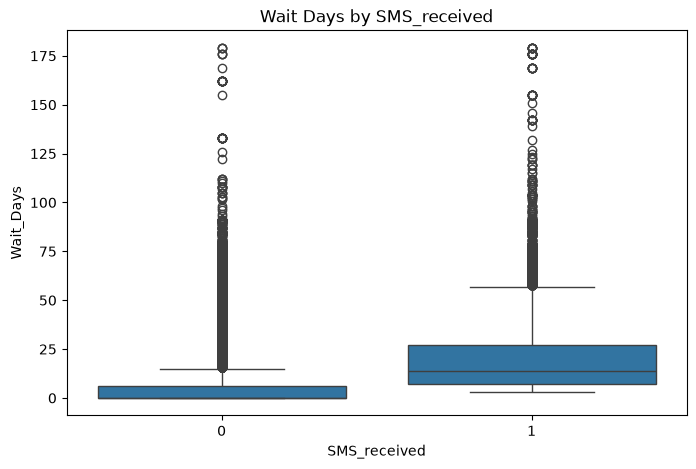

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='SMS_received', y='Wait_Days', data=df)
plt.title('Wait Days by SMS_received')
plt.savefig('visuals/waitdays_vs_sms.png')
plt.show()

## 6g. Interpretation: The SMS Reminder Paradox Explained

The earlier finding that patients who received an SMS reminder had a higher no-show rate (27.6% vs 16.7%) is not because the reminder failed or backfired. It is explained by wait time: patients who received an SMS waited a median of 14 days between booking and their appointment, compared to a median of 0 days for those who did not receive one. Clinics appear to only send SMS reminders when there is enough lead time to do so, and a longer gap between booking and the appointment date is independently associated with a higher chance of missing it, likely because more time passes for circumstances to change, or for the appointment to simply be forgotten. This is a case where two variables (SMS_received and Wait_Days) are entangled, and the SMS reminder itself is not the cause of the higher no-show rate.

## 6h. Appointments Over Time
Checking the distribution of appointments by month, to understand the shape of the dataset over time and investigate any unusual dips

In [38]:
df['AppointmentMonth'] = df['AppointmentDay'].dt.to_period('M')
df.groupby('AppointmentMonth').size()

C:\Users\USER\AppData\Local\Temp\ipykernel_1464\3163700572.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['AppointmentMonth'] = df['AppointmentDay'].dt.to_period('M')


AppointmentMonth
2016-04     3235
2016-05    80836
2016-06    26450
Freq: M, dtype: int64

## 6i. Interpretation of Appointments Over Time

The dataset spans only three months: April 2026 (3,235 appointments, a partial month), May 2026 (80,836 appointments, the only genuinely complete month), and June 2026 (26,450 appointments, also partial). The apparent dip visible in the time trend chart reflects this boundary between partial and full months, not a real drop in appointment volume. Any time based analysis in this dataset should be treated with this limitation in mind, the dataset does not span enough time to draw seasonal or long term trend conclusions.

## 7. Correlation Heatmap

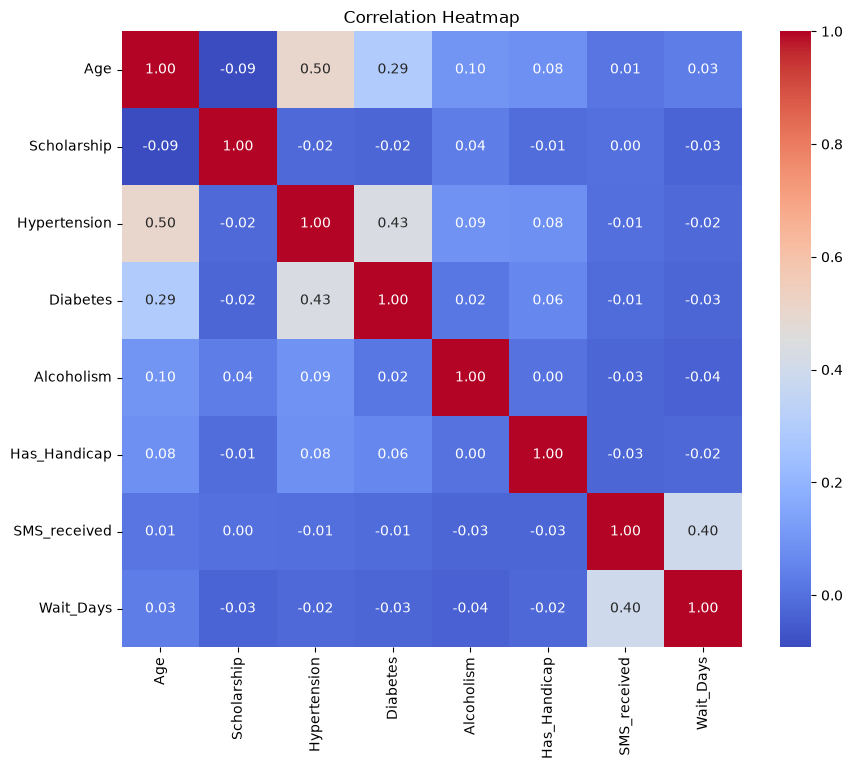

In [33]:
plt.figure(figsize=(10, 8))
corr_cols = ['Age', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Has_Handicap', 'SMS_received', 'Wait_Days']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('visuals/correlation_heatmap.png')
plt.show()

## 7b. Interpretation of Correlation Heatmap

- The strongest relationship in the dataset is between SMS_received and Wait_Days (0.40), confirming that SMS reminders are associated with longer gaps between booking and appointment, which explains the earlier no-show pattern.
- Age correlates moderately with Hypertension (0.50) and Diabetes (0.29), consistent with these conditions becoming more common with age.
- Hypertension and Diabetes correlate with each other (0.43), reflecting that these conditions commonly occur together.
- Scholarship, Alcoholism, and Has_Handicap show weak correlations with everything else, no strong linear relationships detected.

# 8. Save the cleaned data in CSV format

In [34]:
df.to_csv('data/clean/medical_noshow_clean.csv', index=False)
print("Cleaned dataset exported")

Cleaned dataset exported


## 9. Load Cleaned Data into SQL Database

In [35]:
import pyodbc
print([x for x in pyodbc.drivers() if 'SQL Server' in x])

['SQL Server', 'ODBC Driver 17 for SQL Server', 'ODBC Driver 18 for SQL Server']


# 9a. Connect to SQL Server

First establish a connection to the SQL Server instance itself (via the master database, SQL Server's default system database) to confirm credentials and driver setup work before creating a dedicated database.

In [36]:
import pyodbc
import sqlalchemy
from sqlalchemy import create_engine
import urllib

server = r"localhost\SQLEXPRESS"
database = "master"

conn_str = (
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"Trusted_Connection=yes;"
)

params = urllib.parse.quote_plus(conn_str)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

with engine.connect() as test_conn:
    print("Connected successfully!")

Connected successfully!


# 9b. Create a Dedicated Database

In [37]:
autocommit_engine = engine.execution_options(isolation_level="AUTOCOMMIT")

with autocommit_engine.connect() as conn:
    conn.execute(sqlalchemy.text("CREATE DATABASE MEDICALNOSHOWDB"))
    print("Database 'MEDICALNOSHOWDB' created.")

ProgrammingError: (pyodbc.ProgrammingError) ('42000', "[42000] [Microsoft][ODBC Driver 17 for SQL Server][SQL Server]Database 'MEDICALNOSHOWDB' already exists. Choose a different database name. (1801) (SQLExecDirectW)")
[SQL: CREATE DATABASE MEDICALNOSHOWDB]
(Background on this error at: https://sqlalche.me/e/20/f405)

# 9c. Reconnect to the New Database

In [ ]:
database = "MEDICALNOSHOWDB"

conn_str = (
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"Trusted_Connection=yes;"
)

params = urllib.parse.quote_plus(conn_str)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

with engine.connect() as test_conn:
    print(f"Connected to {database} successfully!")

# 9d. Upload the Cleaned Data to SQL Server
Push the clean DataFrame (from Section 6) into SQL Server as a table called appointment, so we can query it with real T-SQL.

In [ ]:
df.to_sql('appointments', engine, if_exists='replace', index=False)
print("Data uploaded to SQL Server table 'appointments'")

In [ ]:
from sqlalchemy import DateTime

df.to_sql(
    'appointments',
    engine,
    if_exists='replace',
    index=False,
    dtype={
        'ScheduledDay': DateTime(),
        'AppointmentDay': DateTime()
    }
)
print("Table refreshed with fully cleaned data")

## 10. SQL Query 1: Overall No_show Rate

In [ ]:
query = "SELECT TOP 1 * FROM appointments;"
pd.read_sql_query(query, engine)

In [ ]:
query = """
SELECT [No_show], COUNT(*) as total
FROM appointments
GROUP BY [No_show];
"""

pd.read_sql_query(query, engine)

In [ ]:
query = "SELECT TOP 1 * FROM appointments;"
pd.read_sql_query(query, engine)

In [ ]:
from sqlalchemy import text

In [ ]:
with engine.connect() as connection:
    connection.execute(text("EXEC sp_rename 'appointments.Hipertension', 'Hypertension', 'COLUMN'"))
    connection.commit()
print("Column renamed to Hypertension")

In [ ]:
df.columns.tolist()

## 11. SQL Query 2: No_show Rate by Gender

In [ ]:
query = """
SELECT 
    Gender,
    [No_show],
    COUNT(*) as total
FROM appointments
GROUP BY Gender, [No_show]
ORDER BY Gender, [No_show];
"""

pd.read_sql_query(query, engine)

## 12. SQL Query 3: No_show Rate by SMS_received

In [ ]:
query = """
SELECT 
    SMS_received,
    [No_show],
    COUNT(*) as total
FROM appointments
GROUP BY SMS_received, [No_show]
ORDER BY SMS_received, [No_show];
"""

pd.read_sql_query(query, engine)

## 13. SQL Query 4: No_show Rate by SMS_received (Calculated as Percentage)

In [ ]:
query = """
SELECT 
    SMS_received,
    SUM(CASE WHEN [No_show] = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS no_show_rate_percent,
    COUNT(*) as total
FROM appointments
GROUP BY SMS_received;
"""

pd.read_sql_query(query, engine)

In [ ]:
query = """
SELECT 
    SMS_received,
    AVG(CAST(Wait_Days AS FLOAT)) as avg_wait_days,
    MIN(Wait_Days) as min_wait_days,
    MAX(Wait_Days) as max_wait_days
FROM appointments
GROUP BY SMS_received;
"""

pd.read_sql_query(query, engine)

In [ ]:
df.columns.tolist()

In [ ]:
query = "SELECT TOP 1 * FROM appointments;"
pd.read_sql_query(query, engine)

In [ ]:
df.columns.tolist()

In [ ]:
from sqlalchemy import DateTime

df.to_sql(
    'appointments',
    engine,
    if_exists='replace',
    index=False,
    dtype={
        'ScheduledDay': DateTime(),
        'AppointmentDay': DateTime()
    }
)
print("Table refreshed with fully cleaned data")

In [ ]:
query = "SELECT TOP 1 * FROM appointments;"
pd.read_sql_query(query, engine)

In [ ]:
query = """
SELECT 
    SMS_received,
    AVG(CAST(Wait_Days AS FLOAT)) as avg_wait_days,
    MIN(Wait_Days) as min_wait_days,
    MAX(Wait_Days) as max_wait_days
FROM appointments
GROUP BY SMS_received;
"""

pd.read_sql_query(query, engine)

## 14. SQL Query 6: No_show Rate by Neighbourhood (Top 10 by Volume)

In [ ]:
query = "SELECT TOP 1 * FROM appointments;"
result = pd.read_sql_query(query, engine)
print(result.columns.tolist())

In [ ]:
query = """
SELECT TOP 10
    Neighbourhood,
    COUNT(*) as total_appointments,
    SUM(CASE WHEN No_show = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS no_show_rate_percent
FROM appointments
GROUP BY Neighbourhood
ORDER BY total_appointments DESC;
"""

pd.read_sql_query(query, engine)

## 14b. Interpretation of No_show Rate by Neighbourhood

Among the 10 busiest neighbourhoods by appointment volume, no-show rates range from 15.8% (Santa Martha) to 26.3% (Itararé), a meaningful spread rather than random variation. Itararé and Jesus de Nazareth show notably higher no-show rates than the dataset average of roughly 20%, while Santa Martha and Jardim da Penha show notably lower rates. This suggests neighbourhood-level factors, such as distance to the clinic or local transport access, may be worth investigating further, though this dataset alone cannot confirm the cause.